In [2]:
import argparse
import logging
import math
import time
from distutils.util import strtobool
from pathlib import Path
from collections import namedtuple

import cv2
import numpy as np
import torch
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import dsacstar
from ace_network import Regressor
from dataset import CamLocDataset

from ace_util import get_pixel_grid, to_homogeneous
import ace_vis_util as vutil
from ace_visualizer import ACEVisualizer

In [3]:
SCENE_NAME = 'Cambridge_' + 'KingsCollege' # KingsCollege
MASK_METHOD = 'sfm'
SUFFIX = '_conf'

MASK_METHOD_SUFFIX = '' if MASK_METHOD == 'no' else f'_{MASK_METHOD}'

Options = namedtuple('Options', [
    'scene',
    'network',
    'encoder_path',
    'image_resolution',
    'hypotheses',
    'threshold',
    'inlieralpha',
    'maxpixelerror',
    'depth_min', # from ace_trainer.py
])
opt = Options(
    scene=f'datasets/{SCENE_NAME}',
    network=f'output/{SCENE_NAME}{MASK_METHOD_SUFFIX}{SUFFIX}.pt',
    encoder_path='./ace_encoder_pretrained.pt',
    image_resolution=480,
    hypotheses=64,
    threshold=10,
    inlieralpha=100,
    maxpixelerror=100,
    depth_min=0.1,
)

In [4]:
device = torch.device("cuda")
num_workers = 6

scene_path = Path(opt.scene)
head_network_path = Path(opt.network)
encoder_path = Path(opt.encoder_path)

# Load network weights.
encoder_state_dict = torch.load(encoder_path, map_location="cpu")
print(f"Loaded encoder from: {encoder_path}")
head_state_dict = torch.load(head_network_path, map_location="cpu")
print(f"Loaded head weights from: {head_network_path}")

# Create regressor.
network = Regressor.create_from_split_state_dict(encoder_state_dict, head_state_dict)

# Setup for evaluation.
network = network.to(device)
_ = network.eval()

Loaded encoder from: ace_encoder_pretrained.pt
Loaded head weights from: output/Cambridge_KingsCollege_sfm_conf.pt


In [5]:
# Setup dataset.
testset = CamLocDataset(
    scene_path / "test",
    mode=0,  # Default for ACE, we don't need scene coordinates/RGB-D.
    image_height=opt.image_resolution,
)
print(f'Test images found: {len(testset)}')

# subset_idx = np.random.choice(len(testset), 3, replace=False)
subset_idx = np.arange(32, 35)

testset = torch.utils.data.Subset(testset, subset_idx)
print(f'Pick images for testing: {len(testset)}')

# Setup dataloader. Batch size 1 by default.
testset_loader = DataLoader(testset, shuffle=False, num_workers=6)

Test images found: 343
Pick images for testing: 3


In [6]:
def calc_pose_error(frame_idx, scene_coordinates_3HW, conf_1HW, gt_pose_44, intrinsics_33, frame_path, sampling_method='uniform'):
    # Extract focal length and principal point from the intrinsics matrix.
    focal_length = intrinsics_33[0, 0].item()
    ppX = intrinsics_33[0, 2].item()
    ppY = intrinsics_33[1, 2].item()
    # We support a single focal length.
    assert torch.allclose(intrinsics_33[0, 0], intrinsics_33[1, 1])

    # Remove path from file name
    frame_name = Path(frame_path).name

    # Allocate output variable.
    out_pose = torch.zeros((4, 4))
    SAMPLING_METHODS = {'uniform': 0, 'confidence': 1}

    conf_HW = conf_1HW.squeeze(0)
    conf_inlier_threshold = conf_1HW[conf_1HW > 1e-6].mean().item()

    # Compute the pose via RANSAC.
    inlier_map = dsacstar.forward_rgb(
        scene_coordinates_3HW.unsqueeze(0),
        conf_HW,
        out_pose,
        opt.hypotheses,
        opt.threshold,
        conf_inlier_threshold,
        focal_length,
        ppX,
        ppY,
        opt.inlieralpha,
        opt.maxpixelerror,
        network.OUTPUT_SUBSAMPLE,
        SAMPLING_METHODS[sampling_method],
    )

    # Calculate translation error.
    t_err = float(torch.norm(gt_pose_44[0:3, 3] - out_pose[0:3, 3]))

    # Rotation error.
    gt_R = gt_pose_44[0:3, 0:3].numpy()
    out_R = out_pose[0:3, 0:3].numpy()

    r_err = np.matmul(out_R, np.transpose(gt_R))
    # Compute angle-axis representation.
    r_err = cv2.Rodrigues(r_err)[0]
    # Extract the angle.
    r_err = np.linalg.norm(r_err) * 180 / math.pi

    return t_err, r_err, out_pose, inlier_map

In [7]:
def calc_reproj_error(pred_scene_coords_N3, target_px_2, pose_inv_44, K_33):
    pose_inv_34 = pose_inv_44[:3, :]
    pred_scene_coords_N4 = to_homogeneous(pred_scene_coords_N3)
    pred_cam_coords_N3 = pred_scene_coords_N4 @ pose_inv_34.t()
    pred_px_N3 = pred_cam_coords_N3 @ K_33.t()
    # Avoid division by zero.
    pred_px_N3[:, 2].clamp_(min=opt.depth_min)
    pred_px_N2 = pred_px_N3[:, :2] / pred_px_N3[:, 2, None]

    # Measure reprojection error.
    reproj_error_2 = pred_px_N2.squeeze() - target_px_2
    reproj_error_1 = torch.norm(reproj_error_2, dim=1, keepdim=True, p=2)
    return reproj_error_1

Sampling 64 hypotheses.
Done in 0.00713409s.
Calculating scores.
Done in 0.00295275s.
Drawing final hypothesis.
Soft inlier count: 10.9168 (Selection Probability: 4%)
Entropy of hypothesis distribution: 5.10987
Done in 1.9069e-05s.
Refining winning pose:
Done in 0.00375675s.
Rotation Error: 1.01deg, Translation Error: 45.8cm

Sampling 64 hypotheses.
Done in 0.0240986s.
Calculating scores.
Done in 0.00186673s.
Drawing final hypothesis.
Soft inlier count: 0.840995 (Selection Probability: 2%)
Entropy of hypothesis distribution: 5.94417
Done in 1.258e-05s.
Refining winning pose:
Done in 0.000810433s.
Rotation Error: 0.83deg, Translation Error: 73.5cm

Sampling 64 hypotheses.
Done in 0.00461083s.
Calculating scores.
Done in 0.00188813s.
Drawing final hypothesis.
Soft inlier count: 20.8173 (Selection Probability: 7%)
Entropy of hypothesis distribution: 4.65402
Done in 1.2929e-05s.
Refining winning pose:
Done in 0.00517858s.
Rotation Error: 0.79deg, Translation Error: 34.3cm



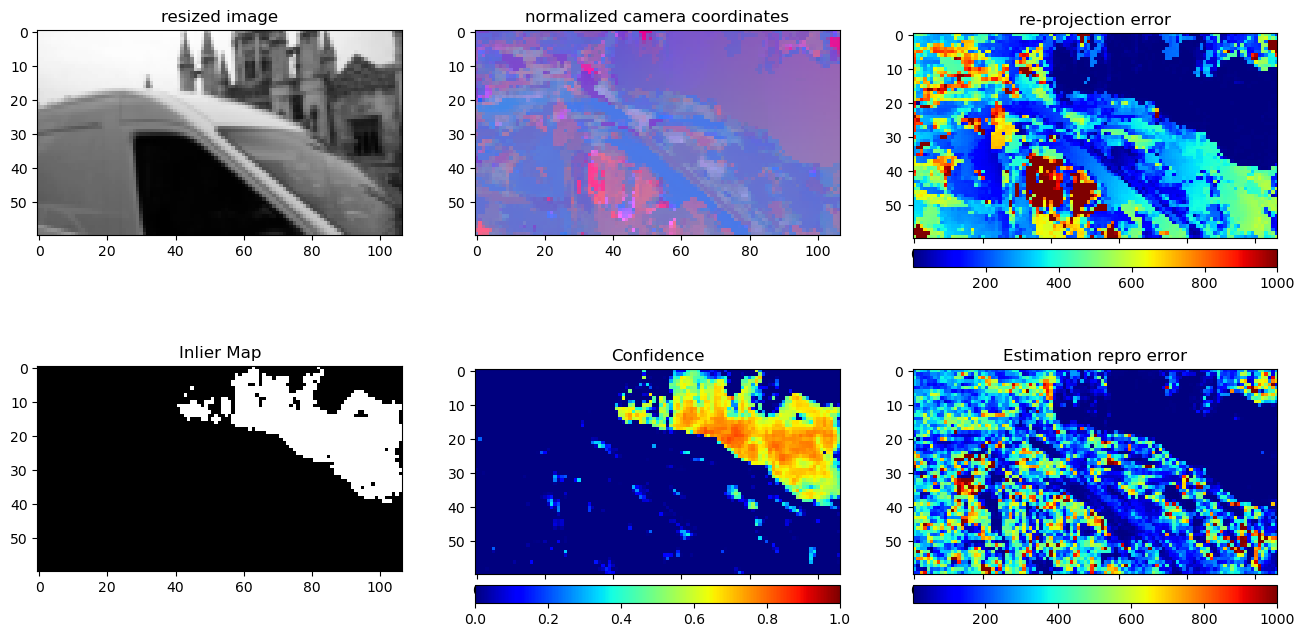

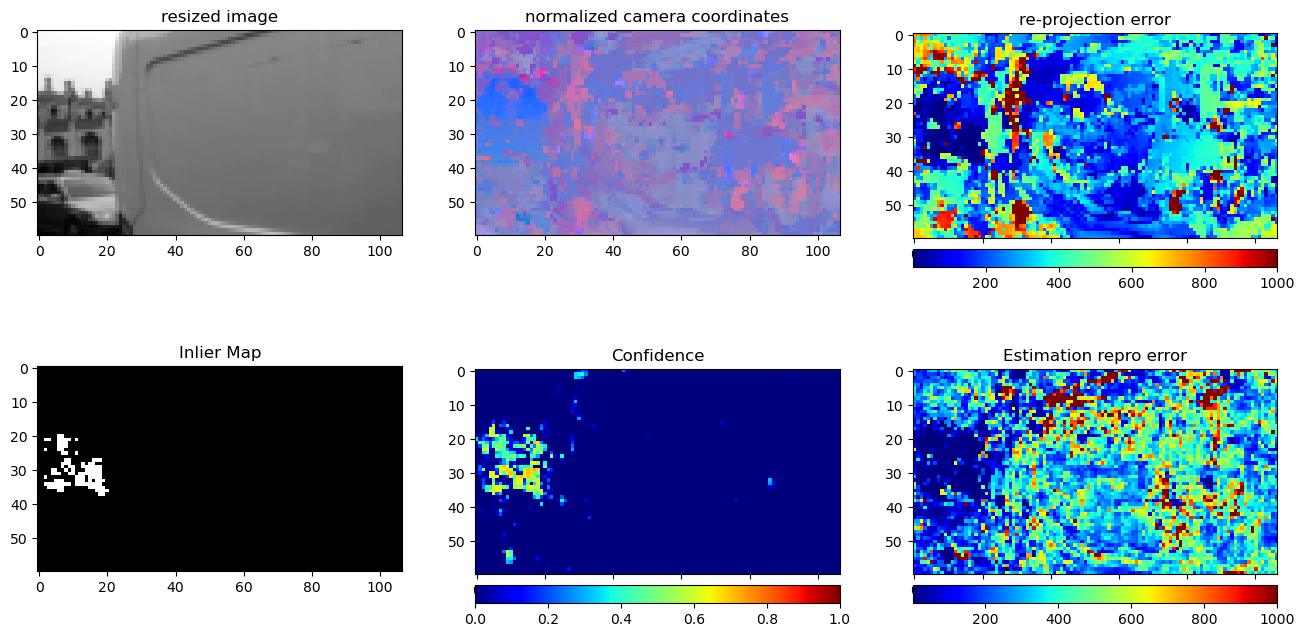

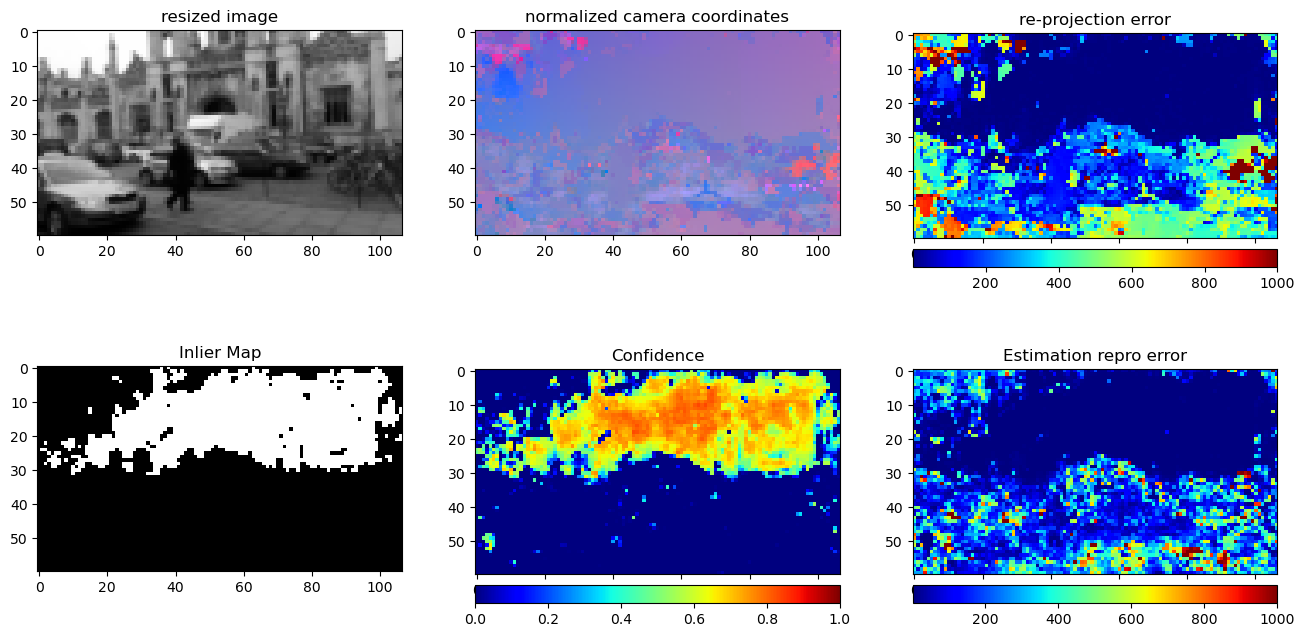

In [13]:
pixel_grid_2HW = get_pixel_grid(network.OUTPUT_SUBSAMPLE)

with torch.no_grad():
    for (image_B1HW, _, _,
        gt_pose_B44, _,
        intrinsics_B33, _,
        _, filenames, info) in testset_loader:
        batch_start_time = time.time()
        batch_size = image_B1HW.shape[0]

        image_B1HW = image_B1HW.to(device, non_blocking=True)

        # Predict scene coordinates.
        with autocast(enabled=True):
            # scene_coordinates_B3HW = network(image_B1HW)
            features = network.get_features(image_B1HW)
            scene_coordinates_B3HW, est_log_err_B1HW = network.get_scene_coordinates(features)
        
        # We need them on the CPU to run RANSAC.
        scene_coordinates_B3HW = scene_coordinates_B3HW.float().cpu()
        est_err_B1HW = est_log_err_B1HW.exp().float().cpu()

        soft_conf_alpha = 5
        conf_B1HW = torch.exp(-est_err_B1HW / soft_conf_alpha)
        # conf_B1HW = (conf_B1HW - conf_B1HW.min()) / (conf_B1HW.max() - conf_B1HW.min())

        B, _, H, W = scene_coordinates_B3HW.shape


        pixel_positions_2HW = pixel_grid_2HW[:, :H, :W].clone()  # It's 2xHxW (actual H and W) now.
        target_px_2 = pixel_positions_2HW.permute(1,2,0).reshape(-1, 2)

        # Each frame is processed independently.
        for frame_idx, (pred_scene_coords_3HW, est_err_1HW, conf_1HW, gt_pose_44, intrinsics_33, frame_path) in enumerate(
                zip(scene_coordinates_B3HW, est_err_B1HW, conf_B1HW, gt_pose_B44, intrinsics_B33, filenames)):
                
                for i in range(1):
                    plt.figure(figsize=(16, 8))

                    # === Original Image ===
                    plt.subplot(2, 3, 1)
                    resized_image_1HW = TF.resize(image_B1HW[0], (H, W), antialias=True).cpu()
                    plt.imshow(resized_image_1HW[0].numpy(), cmap='gray')
                    plt.title('resized image')

                    gt_inv_poses_44 = torch.inverse(gt_pose_44)
                    gt_inv_poses_34 = gt_inv_poses_44[:3]
                    K_33 = intrinsics_33.clone()

                    pred_scene_coords_N3 = pred_scene_coords_3HW.permute(1, 2, 0).flatten(0, 1).float()
                    pred_scene_coords_N4 = to_homogeneous(pred_scene_coords_N3)
                    pred_cam_coords_N3 = pred_scene_coords_N4 @ gt_inv_poses_34.t()
                    # pred_px_N3 = pred_cam_coords_N3 @ K_33.t()
                    # # Avoid division by zero.
                    # pred_px_N3[:, 2].clamp_(min=opt.depth_min)
                    # pred_px_N2 = pred_px_N3[:, :2] / pred_px_N3[:, 2, None]

                    # # Measure reprojection error.
                    # reproj_error_2 = pred_px_N2.squeeze() - target_px_2
                    # reproj_error_1 = torch.norm(reproj_error_2, dim=1, keepdim=True, p=2)
                    reproj_error_1 = calc_reproj_error(pred_scene_coords_N3, target_px_2, gt_inv_poses_44, K_33)
                    reproj_error_HW = reproj_error_1.reshape(H, W)

                    # Calculate pose error.
                    t_err, r_err, pred_pose, inlier_map = calc_pose_error(
                        frame_idx, pred_scene_coords_3HW, 
                        conf_1HW,
                        gt_pose_44, intrinsics_33, frame_path,
                        'confidence'
                    )

                    pred_inv_pose = torch.inverse(pred_pose)
                    pred_pose_reproj_error_1 = calc_reproj_error(pred_scene_coords_N3, target_px_2, pred_inv_pose, K_33)
                    pred_pose_reproj_error_HW = pred_pose_reproj_error_1.reshape(H, W)

                    # inlier_reproj_error = reproj_error_HW[inlier_map > 0]
                    print(f"Rotation Error: {r_err:.2f}deg, Translation Error: {t_err * 100:.1f}cm")
                    # print(f"Inlier Reprojection Error: {inlier_reproj_error.mean():.1f} ± {inlier_reproj_error.std():.1f}, {inlier_reproj_error.median():.1f}")
                    # print(f"Reproj error residual: {(pred_pose_reproj_error_1.clip(0, 1000) - reproj_error_1.clip(0, 1000)).abs().sum() / (H*W):.1f}")
                    print()

                    MASK_OUT_HIGH_REPRO_ERROR = False
                    if MASK_OUT_HIGH_REPRO_ERROR:
                        low_reproj_error_mask_HW = reproj_error_HW <= 10
                        print('Number of low reproj error pixels:', low_reproj_error_mask_HW.sum().item())

                    # === Re-projection Error ===
                    reproj_error_img = reproj_error_HW.clip(0, 1000)
                    if MASK_OUT_HIGH_REPRO_ERROR:
                        reproj_error_img[~low_reproj_error_mask_HW] = 0
                    plt.subplot(2, 3, 3)
                    plt.imshow(reproj_error_img.numpy(), cmap='jet')
                    plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    plt.title('re-projection error')

                    # === Predicted Pose Re-projection Error ===
                    # pred_pose_reproj_error_img = pred_pose_reproj_error_HW.clip(0, 1000)
                    # if MASK_OUT_HIGH_REPRO_ERROR:
                    #     pred_pose_reproj_error_img[~low_reproj_error_mask_HW] = 0
                    # plt.subplot(2, 3, 2)
                    # plt.imshow(pred_pose_reproj_error_img.numpy(), cmap='jet')
                    # plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    # plt.title('pred pose re-projection error')

                    # === Scene coordinate ===
                    # pred_scene_coords_img = pred_scene_coords_N3.reshape(H, W, 3)
                    # pred_scene_coords_img = pred_scene_coords_img.clip(-50, 50)
                    # norm_pred_scene_coords_img = (pred_scene_coords_img - pred_scene_coords_img.min()) \
                    #     / (pred_scene_coords_img.max() - pred_scene_coords_img.min())
                    # plt.subplot(2, 3, 2)
                    # plt.imshow(norm_pred_scene_coords_img.numpy())
                    # plt.title('normalized scene coordinates')

                    # === Camera coordinate ===
                    pred_cam_coords_img = pred_cam_coords_N3.reshape(H, W, 3)
                    pred_cam_coords_img = pred_cam_coords_img.clip(-50, 50)
                    norm_pred_cam_coords_img = (pred_cam_coords_img - pred_cam_coords_img.min()) \
                        / (pred_cam_coords_img.max() - pred_cam_coords_img.min())
                    plt.subplot(2, 3, 2)
                    plt.imshow(norm_pred_cam_coords_img.numpy())
                    plt.title('normalized camera coordinates')

                    # === Sobel ===
                    # sobel_x = cv2.Sobel(pred_cam_coords_img.numpy(), cv2.CV_64F, 1, 0, ksize=5).mean(axis=2)
                    # sobel_y = cv2.Sobel(pred_cam_coords_img.numpy(), cv2.CV_64F, 0, 1, ksize=5).mean(axis=2)
                    # sobel = np.sqrt(sobel_x**2 + sobel_y**2)
                    # if MASK_OUT_HIGH_REPRO_ERROR:
                    #     sobel[~low_reproj_error_mask_HW] = 0
                    # norm_sobel = sobel / (sobel.max() - sobel.min())
                    # plt.subplot(2, 3, 4)
                    # plt.imshow(norm_sobel, cmap='jet', vmin=0, vmax=1)
                    # plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    # plt.title('sobel')

                    # === Laplacian ===
                    # laplacian = cv2.Laplacian(pred_cam_coords_img.numpy().astype(np.float64), cv2.CV_64F)
                    # laplacian = laplacian.mean(axis=2)
                    # if MASK_OUT_HIGH_REPRO_ERROR:
                    #     laplacian[~low_reproj_error_mask_HW] = 0
                    # norm_laplacian = np.zeros_like(laplacian)
                    # norm_laplacian[laplacian > 0] = laplacian[laplacian > 0] / max(laplacian.max(), -laplacian.min())
                    # norm_laplacian[laplacian < 0] = laplacian[laplacian < 0] / max(laplacian.max(), -laplacian.min())
                    # plt.subplot(2, 3, 5)
                    # plt.imshow(norm_laplacian, cmap='bwr', vmin=-1, vmax=1)
                    # plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    # plt.title('laplacian')

                    # === Estimated Re-projection Error ===
                    est_err_img = est_err_1HW[0].numpy().clip(0, 1000)
                    if MASK_OUT_HIGH_REPRO_ERROR:
                        est_err_img[~low_reproj_error_mask_HW] = 0
                    plt.subplot(2, 3, 6)
                    plt.imshow(est_err_img, cmap='jet')#, vmin=0, vmax=1)
                    plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    plt.title('Estimation repro error')

                    # === Confidences ===
                    conf_img = conf_1HW[0].numpy()
                    # conf_img = (conf_img - conf_img.min()) / (conf_img.max() - conf_img.min())
                    if MASK_OUT_HIGH_REPRO_ERROR:
                        conf_img[~low_reproj_error_mask_HW] = 0
                    plt.subplot(2, 3, 5)
                    plt.imshow(conf_img, cmap='jet', vmin=0, vmax=1)
                    plt.colorbar(orientation='horizontal', fraction=0.047*(W/H), pad=0.04)
                    plt.title('Confidence')

                    # === Inlier Map ===
                    plt.subplot(2, 3, 4)
                    plt.imshow(inlier_map.numpy(), cmap='gray')
                    plt.title('Inlier Map')

                    # # === Reverse order mask ===
                    # pred_px_2HW = pred_px_N2.reshape(H, W, 2).permute(2, 0, 1)
                    # roll_px = torch.roll(pred_px_2HW, shifts=(-1, -1), dims=(1, 2))
                    # H_rev_order_mask = (roll_px[0] - pred_px_2HW[0]) < 0
                    # W_rev_order_mask = (roll_px[1] - pred_px_2HW[1]) < 0
                    # rev_order_mask = torch.zeros((H, W, 3))
                    # rev_order_mask[:, :, 0] = W_rev_order_mask
                    # rev_order_mask[:, :, 2] = H_rev_order_mask
                    # rev_order_mask[:, :, 1] = H_rev_order_mask * W_rev_order_mask
                    # plt.subplot(2, 3, 6)
                    # plt.imshow(rev_order_mask.numpy(), cmap='gray')
                    # plt.title('pixel coordinates')

In [ ]:
import plotly.express as px
import plotly.figure_factory as ff

conf_inlier_threshold = np.exp(-np.log(opt.threshold) / soft_conf_alpha)
conf = conf_1HW.flatten().numpy()
conf_gt0 = conf[conf > 1e-6]

print(np.quantile(conf_gt0, 0.5))

# print('conf inlier threshold:', conf_inlier_threshold) 
# print('conf inlier q', q)
# print(sum(conf > q) / len(conf))

px.histogram(conf_gt0, marginal='box').show()
# ff.create_distplot([conf], ['confidence'], bin_size=0.01).show()